In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import spacy
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm


In [2]:
# Temel sabitler tanimlanir.
NEWS_DATASET_PATH = Path("dataset/MINDsmall_train/news.tsv")
BEHAVIORS_DATASET_PATH = Path("dataset/MINDsmall_train/behaviors.tsv")
NEWS_COLUMNS = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities",
]
BEHAVIOR_COLUMNS = ["impression_id", "user_id", "time", "history", "impressions"]
MIN_HISTORY_LENGTH = 40
MAX_SAMPLES_PER_CLASS = 2500
TRAIN_RATIO = 0.7
RANDOM_STATE = 42

In [3]:
# Ham verileri yukleyip ozetler.
news_df = pd.read_csv(NEWS_DATASET_PATH, sep="\t", header=None, names=NEWS_COLUMNS)
behaviors_df = pd.read_csv(
    BEHAVIORS_DATASET_PATH, sep="\t", header=None, names=BEHAVIOR_COLUMNS
)
news_df["title"] = news_df["title"].fillna("").str.strip()
title_map = news_df.set_index("news_id")["title"].to_dict()

raw_summary_df = pd.DataFrame(
    {
        "dataset": ["news_df", "behaviors_df"],
        "rows": [len(news_df), len(behaviors_df)],
        "columns": [news_df.shape[1], behaviors_df.shape[1]],
    }
)
display(raw_summary_df)


,dataset,rows,columns
0,news_df,51282,8
1,behaviors_df,156965,5


In [4]:
# History metnini ve split alanini hazirlar.
def build_history_text(history):
    history_titles = []
    for news_id in history.split():
        title = title_map.get(news_id, "")
        if title:
            history_titles.append(title)
    return " ".join(history_titles)

behaviors_df["history"] = behaviors_df["history"].fillna("")
behaviors_df["impressions"] = behaviors_df["impressions"].fillna("")
behaviors_df["history_len"] = behaviors_df["history"].str.split().str.len()
behaviors_df = behaviors_df.loc[behaviors_df["history_len"] >= MIN_HISTORY_LENGTH].copy()
behaviors_df["time"] = pd.to_datetime(
    behaviors_df["time"], format="%m/%d/%Y %I:%M:%S %p"
)
behaviors_df = behaviors_df.sort_values(["user_id", "time"]).copy()
behaviors_df["history_text"] = behaviors_df["history"].map(build_history_text)
behaviors_df["user_row_index"] = behaviors_df.groupby("user_id").cumcount()
behaviors_df["user_row_count"] = behaviors_df.groupby("user_id")["impression_id"].transform("size")
behaviors_df["split"] = "test"
behaviors_df.loc[
    behaviors_df["user_row_index"] < (behaviors_df["user_row_count"] * TRAIN_RATIO).astype(int),
    "split",
] = "train"

behavior_summary_df = pd.DataFrame(
    {
        "metric": [
            "filtered_rows",
            "unique_users",
            "train_rows",
            "test_rows",
        ],
        "value": [
            len(behaviors_df),
            behaviors_df["user_id"].nunique(),
            int((behaviors_df["split"] == "train").sum()),
            int((behaviors_df["split"] == "test").sum()),
        ],
    }
)
display(behavior_summary_df)


,metric,value
0,filtered_rows,42018
1,unique_users,5651
2,train_rows,26781
3,test_rows,15237


In [5]:
# Bazi kullanici history orneklerini gosterir.
example_user_ids = behaviors_df["user_id"].drop_duplicates().head(3)
user_history_examples_df = behaviors_df.loc[
    behaviors_df["user_id"].isin(example_user_ids),
    ["user_id", "time", "split", "history"],
].copy()
user_history_examples_df["history_news_ids_preview"] = (
    user_history_examples_df["history"].str.split().str[:12].str.join(" ")
)
user_history_examples_df = user_history_examples_df[
    ["user_id", "time", "split", "history_news_ids_preview"]
].head(9)
display(user_history_examples_df)


,user_id,time,split,history_news_ids_preview
106295,U10027,2019-11-12 08:00:33,train,N3850 N6354 N56490 N61826 N45286 N30965 N10629...
134156,U10027,2019-11-12 10:50:58,train,N3850 N6354 N56490 N61826 N45286 N30965 N10629...
136995,U10027,2019-11-12 13:06:20,train,N3850 N6354 N56490 N61826 N45286 N30965 N10629...
50069,U10027,2019-11-13 05:24:08,train,N3850 N6354 N56490 N61826 N45286 N30965 N10629...
107211,U10027,2019-11-13 05:24:09,test,N3850 N6354 N56490 N61826 N45286 N30965 N10629...
28114,U10027,2019-11-14 05:32:02,test,N3850 N6354 N56490 N61826 N45286 N30965 N10629...
77041,U10027,2019-11-14 11:18:32,test,N3850 N6354 N56490 N61826 N45286 N30965 N10629...
7738,U10045,2019-11-11 09:03:05,train,N52865 N22570 N37481 N55189 N16158 N63276 N150...
137987,U10045,2019-11-11 12:22:40,train,N52865 N22570 N37481 N55189 N16158 N63276 N150...


In [6]:
# Train ve test icin ornek limitlerini belirler.
max_train_samples = int(MAX_SAMPLES_PER_CLASS * TRAIN_RATIO)
max_test_samples = MAX_SAMPLES_PER_CLASS - max_train_samples
sample_limits = {
    "train": {"clicked": max_train_samples, "not_clicked": max_train_samples},
    "test": {"clicked": max_test_samples, "not_clicked": max_test_samples},
}
samples = {
    "train": {"clicked": [], "not_clicked": []},
    "test": {"clicked": [], "not_clicked": []},
}

sample_limits_df = pd.DataFrame(
    [
        {"split": split, "label": label, "limit": sample_limits[split][label]}
        for split in sample_limits
        for label in sample_limits[split]
    ]
)
display(sample_limits_df)


,split,label,limit
0,train,clicked,1750
1,train,not_clicked,1750
2,test,clicked,750
3,test,not_clicked,750


In [7]:
# Siniflandirma orneklerini toplar.
sample_source = behaviors_df[["split", "history_text", "impressions"]]

for row in sample_source.itertuples(index=False):
    split = row.split
    history_text = row.history_text

    for item in row.impressions.split():
        news_id, label = item.rsplit("-", 1)
        candidate_title = title_map.get(news_id, "")

        if not candidate_title:
            continue

        target_label = "clicked" if label == "1" else "not_clicked"

        if len(samples[split][target_label]) >= sample_limits[split][target_label]:
            continue

        combined_text = f"{history_text} {candidate_title}".strip()
        row_data = (news_id, candidate_title, history_text, combined_text, target_label, split)
        samples[split][target_label].append(row_data)

    if all(
        len(samples[current_split][current_label])
        >= sample_limits[current_split][current_label]
        for current_split in sample_limits
        for current_label in sample_limits[current_split]
    ):
        break

In [8]:
# Son interaction tablosunu olusturur.
interaction_df = pd.DataFrame(
    samples["train"]["clicked"]
    + samples["train"]["not_clicked"]
    + samples["test"]["clicked"]
    + samples["test"]["not_clicked"],
    columns=[
        "news_id",
        "candidate_title",
        "history_text",
        "text",
        "label",
        "split",
    ],
).reset_index(drop=True)

interaction_preview_df = interaction_df.assign(
    history_preview=interaction_df["history_text"].str.slice(0, 120)
)[["split", "news_id", "candidate_title", "history_preview", "label"]].head()
display(interaction_preview_df)

,split,news_id,candidate_title,history_preview,label
0,train,N58363,Supreme Court refuses to block lawsuit against...,I Tried DNA Testing to Lose Weight And the Res...,clicked
1,train,N21741,US held record number of migrant children in c...,I Tried DNA Testing to Lose Weight And the Res...,clicked
2,train,N24176,Ree Drummond Says a Low-Carb Diet Is the Secre...,I Tried DNA Testing to Lose Weight And the Res...,clicked
3,train,N27289,Why I'm Done Celebrating The Accomplishments O...,I Tried DNA Testing to Lose Weight And the Res...,clicked
4,train,N6975,Harrods accused of ruining the spirit of Chris...,I Tried DNA Testing to Lose Weight And the Res...,clicked


In [9]:
# Metin ve lemmatization hazirligini yapar.
train_df = interaction_df.loc[interaction_df["split"] == "train"].reset_index(drop=True)
test_df = interaction_df.loc[interaction_df["split"] == "test"].reset_index(drop=True)
train_texts = train_df["text"].tolist()
test_texts = test_df["text"].tolist()
train_labels = train_df["label"].tolist()
test_labels = test_df["label"].tolist()
texts = train_texts + test_texts
labels = train_labels + test_labels
analyzer = spacy.load("en_core_web_sm", disable=["parser", "ner"])
stop_words = analyzer.Defaults.stop_words


def stem_text(text):
    doc = analyzer(text)
    stems = []
    for token in doc:
        lemma = token.lemma_.lower()
        if token.is_alpha and lemma not in stop_words:
            stems.append(lemma)
    return " ".join(stems)


text_setup_df = pd.DataFrame(
    {
        "metric": ["train_text_count", "test_text_count", "unique_labels", "stop_word_count"],
        "value": [len(train_texts), len(test_texts), len(set(labels)), len(stop_words)],
    }
)
display(text_setup_df)

,metric,value
0,train_text_count,3500
1,test_text_count,1500
2,unique_labels,2
3,stop_word_count,326


In [10]:
# Tum metinleri lemmatize eder.
train_cleaned_texts = [stem_text(text) for text in tqdm(train_texts, desc="Train lemmatization", unit="text")]
test_cleaned_texts = [stem_text(text) for text in tqdm(test_texts, desc="Test lemmatization", unit="text")]
cleaned_texts = train_cleaned_texts + test_cleaned_texts

Train lemmatization:   0%|          | 0/3500 [00:00<?, ?text/s]

Test lemmatization:   0%|          | 0/1500 [00:00<?, ?text/s]

In [11]:
# Lemmatization orneklerini gosterir.
sample_lemma_df = pd.DataFrame(
    {
        "split": interaction_df["split"].head(5),
        "candidate_title": interaction_df["candidate_title"].head(5),
        "history_preview": interaction_df["history_text"].str.slice(0, 120).head(5),
        "lemmatized_text": cleaned_texts[:5],
        "label": labels[:5],
    }
)
display(sample_lemma_df)


,split,candidate_title,history_preview,lemmatized_text,label
0,train,Supreme Court refuses to block lawsuit against...,I Tried DNA Testing to Lose Weight And the Res...,try dna testing lose weight result blow mind c...,clicked
1,train,US held record number of migrant children in c...,I Tried DNA Testing to Lose Weight And the Res...,try dna testing lose weight result blow mind c...,clicked
2,train,Ree Drummond Says a Low-Carb Diet Is the Secre...,I Tried DNA Testing to Lose Weight And the Res...,try dna testing lose weight result blow mind c...,clicked
3,train,Why I'm Done Celebrating The Accomplishments O...,I Tried DNA Testing to Lose Weight And the Res...,try dna testing lose weight result blow mind c...,clicked
4,train,Harrods accused of ruining the spirit of Chris...,I Tried DNA Testing to Lose Weight And the Res...,try dna testing lose weight result blow mind c...,clicked


In [12]:
# Etiketleri ve TF-IDF matrisini olusturur.
le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test = le.transform(test_labels)
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_cleaned_texts)
X_test = vectorizer.transform(test_cleaned_texts)
feature_names = vectorizer.get_feature_names_out()

vector_summary_df = pd.DataFrame(
    {
        "metric": ["X_train_rows", "X_test_rows", "X_cols", "label_0", "label_1"],
        "value": [X_train.shape[0], X_test.shape[0], X_train.shape[1], le.classes_[0], le.classes_[1]],
    }
)
display(vector_summary_df)


,metric,value
0,X_train_rows,3500
1,X_test_rows,1500
2,X_cols,5000
3,label_0,clicked
4,label_1,not_clicked


In [13]:
# Bazi TF ve TF-IDF agirliklarini gosterir.
sample_doc_idx = 0
sample_tokens = pd.Series(train_cleaned_texts[sample_doc_idx].split())
sample_tf_df = (
    sample_tokens.value_counts()
    .rename_axis("term")
    .reset_index(name="raw_count")
)
sample_tf_df["tf_weight"] = sample_tf_df["raw_count"] / sample_tf_df["raw_count"].sum()
sample_tfidf_series = pd.Series(
    X_train[sample_doc_idx].toarray().ravel(), index=feature_names, name="tfidf_weight"
)
sample_tf_tfidf_df = sample_tf_df.merge(
    sample_tfidf_series[sample_tfidf_series > 0].reset_index().rename(columns={"index": "term"}),
    on="term",
    how="left",
).sort_values(["tfidf_weight", "tf_weight"], ascending=False).head(10)
display(sample_tf_tfidf_df)


,term,raw_count,tf_weight,tfidf_weight
1,weight,11,0.014946,0.233263
0,trump,15,0.020380,0.209943
6,diet,4,0.005435,0.152422
2,lose,10,0.013587,0.150031
19,workout,3,0.004076,0.122441
9,pound,4,0.005435,0.096095
3,loss,5,0.006793,0.093855
13,pounds,3,0.004076,0.091564
21,walk,3,0.004076,0.091512
53,sequel,2,0.002717,0.086216


In [14]:
# Train uzerinde modelleri egitir ve test uzerinde degerlendirir.
knn = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
cv_knn = cross_val_score(knn, X_train, y_train, cv=10, scoring="accuracy")

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
cv_nb = cross_val_score(nb, X_train, y_train, cv=10, scoring="accuracy")


In [15]:
# Tum model sonuclarini tabloda toplar.
results = pd.DataFrame(
    {
        "KNN": [
            accuracy_score(y_test, y_pred_knn),
            precision_score(y_test, y_pred_knn, average="weighted", zero_division=0),
            recall_score(y_test, y_pred_knn, average="weighted"),
            f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
            cv_knn.mean(),
        ],
        "Naive Bayes": [
            accuracy_score(y_test, y_pred_nb),
            precision_score(y_test, y_pred_nb, average="weighted", zero_division=0),
            recall_score(y_test, y_pred_nb, average="weighted"),
            f1_score(y_test, y_pred_nb, average="weighted", zero_division=0),
            cv_nb.mean(),
        ],
    },
    index=["Accuracy", "Precision", "Recall", "F1", "CV Accuracy"],
)
display(results)


,KNN,Naive Bayes
Accuracy,0.956667,0.864667
Precision,0.960123,0.870870
Recall,0.956667,0.864667
F1,0.956585,0.864098
CV Accuracy,0.938571,0.901429


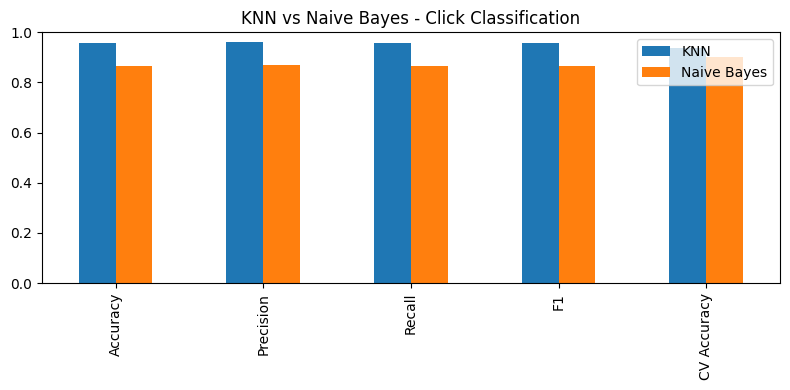

In [16]:
# Sonuc grafigini cizer.
results.plot(kind="bar", figsize=(8, 4))
plt.ylim(0, 1)
plt.title("KNN vs Naive Bayes - Click Classification")
plt.tight_layout()
plt.show()

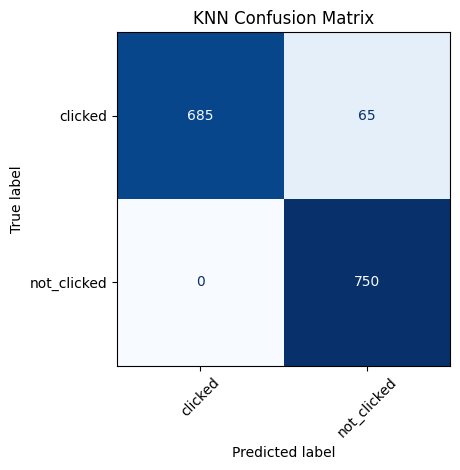

In [17]:
# KNN confusion matrix cizer.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
)

plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()


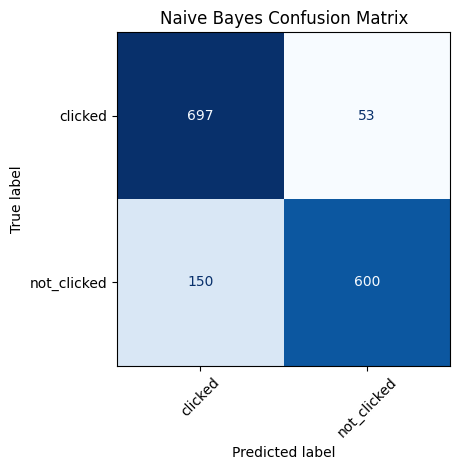

In [18]:
# Naive Bayes confusion matrix cizer.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
)

plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()
